In [1]:
import pandas as pd
df = pd.read_csv("loan_filtered.csv")
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,Apr-2013,119.66,Sep-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
1,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,Jan-2015,357.48,Jan-2015,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
2,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,Jan-2016,67.79,Jan-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
3,1075269,1311441,5000.0,5000.0,5000.0,36 months,7.90,156.46,A,A4,...,Jan-2015,161.03,Sep-2015,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
4,1069639,1304742,7000.0,7000.0,7000.0,60 months,15.96,170.08,C,C5,...,Jan-2016,170.08,Jan-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
5,1072053,1288686,3000.0,3000.0,3000.0,36 months,18.64,109.43,E,E1,...,Jan-2015,111.34,Dec-2014,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
6,1071570,1306721,5375.0,5375.0,5350.0,60 months,12.69,121.45,B,B5,...,Nov-2012,121.45,Mar-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
7,1070078,1305201,6500.0,6500.0,6500.0,60 months,14.65,153.45,C,C3,...,Jun-2013,1655.54,Dec-2015,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
8,1069908,1305008,12000.0,12000.0,12000.0,36 months,12.69,402.54,B,B5,...,Sep-2013,6315.30,Aug-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
9,1064687,1298717,9000.0,9000.0,9000.0,36 months,13.49,305.38,C,C1,...,Jul-2012,305.38,Nov-2012,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045


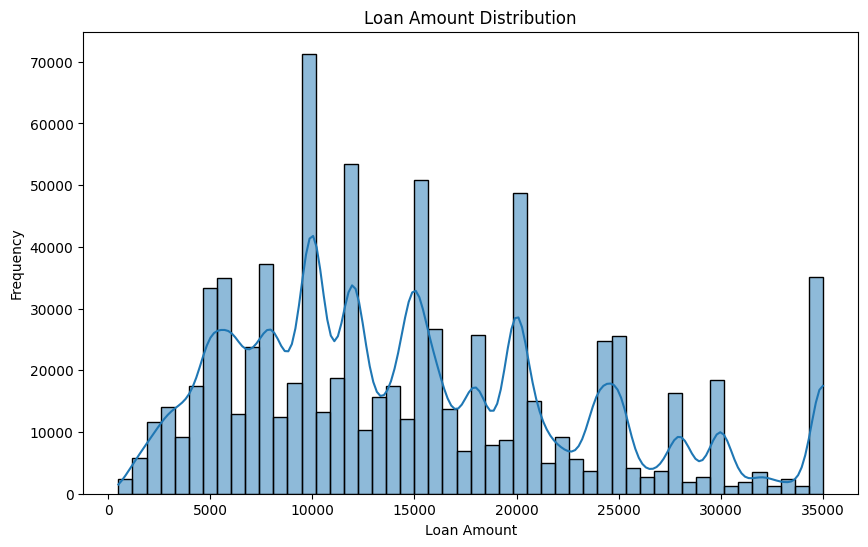

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


# 贷款金额分布的直方图
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amnt'], bins=50, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

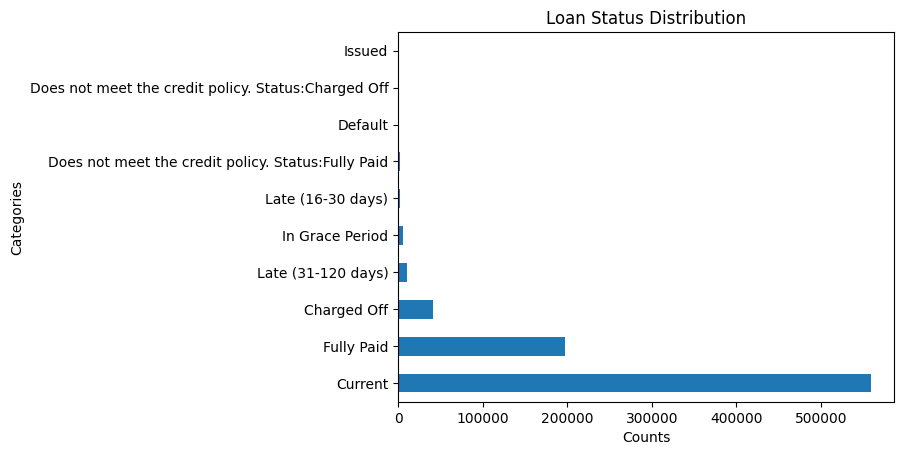

In [3]:
category_counts = df['loan_status'].value_counts()

# 创建横向条形图
category_counts.plot(kind='barh')

# 设置图表标题和坐标轴标签
plt.title('Loan Status Distribution')
plt.xlabel('Counts')
plt.ylabel('Categories')

plt.show()

In [4]:
# ==================== 特征选择（Feature Selection） ====================
# 以下步骤从《1 数据初步清洗》notebook 移入，属于特征工程范畴：
# 1. 删除高基数列（id、url、emp_title 等标识符/近唯一列）
# 2. 删除类别严重不平衡列
# 3. 删除与信用评估无关或冗余的列
# 输入：loan_filtered.csv（52 列，仅完成缺失值处理）
# 输出：进入编码阶段的 df（40 列）
print(f"读入数据维度: {df.shape}")

读入数据维度: (819403, 52)


In [5]:
# 特征选择1：查看各非数值列的唯一值数量，识别高基数列
# （id、member_id、url、emp_title、title、zip_code 等唯一值极多，不具备预测能力）
non_float64_columns = df.select_dtypes(exclude=["float64"])
unique_counts = non_float64_columns.nunique()
print(unique_counts)

id                     819403
member_id              819403
term                        2
grade                       7
sub_grade                  35
emp_title              295476
emp_length                 12
home_ownership              6
verification_status         3
issue_d                   103
loan_status                10
pymnt_plan                  2
url                    819403
purpose                    14
title                   59244
zip_code                  932
addr_state                 51
earliest_cr_line          679
initial_list_status         2
last_pymnt_d               98
last_credit_pull_d        103
application_type            2
dtype: int64


In [6]:
# 删除唯一值 > 697 的高基数列
columns_to_drop = unique_counts[unique_counts > 697].index
df = df.drop(columns=columns_to_drop)
print(f"删除高基数列后维度: {df.shape}")
df.head()

删除高基数列后维度: (819403, 46)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,< 1 year,RENT,...,Apr-2013,119.66,Sep-2013,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
1,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,10+ years,RENT,...,Jan-2015,357.48,Jan-2015,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
2,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,1 year,RENT,...,Jan-2016,67.79,Jan-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
3,5000.0,5000.0,5000.0,36 months,7.90,156.46,A,A4,3 years,RENT,...,Jan-2015,161.03,Sep-2015,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045
4,7000.0,7000.0,7000.0,60 months,15.96,170.08,C,C5,8 years,RENT,...,Jan-2016,170.08,Jan-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,32068.620045


In [7]:
# 特征选择2：检查类别严重不平衡的列
print("pymnt_plan 分布:")
print(df.pymnt_plan.value_counts())
print()
print("application_type 分布:")
print(df.application_type.value_counts())

pymnt_plan 分布:
pymnt_plan
n    819393
y        10
Name: count, dtype: int64

application_type 分布:
application_type
INDIVIDUAL    819080
JOINT            323
Name: count, dtype: int64


In [8]:
# 特征选择3：删除冗余、不平衡、与信用评估无关的列
# - application_type、pymnt_plan：类别极度不平衡（>99.9% 为同一类别）
# - last_pymnt_amnt、last_pymnt_d：还款结果信息，与信用评估存在因果倒置
# - sub_grade：与 grade 高度冗余，保留 grade 即可
# - policy_code：只有唯一一个取值，不含任何信息
cols_to_drop = ["application_type", "pymnt_plan", "last_pymnt_amnt",
                "sub_grade", "policy_code", "last_pymnt_d"]
df = df.drop(columns=cols_to_drop)
print(f"特征选择完成后维度: {df.shape}")

特征选择完成后维度: (819403, 40)


In [9]:
# Data encoding1：将某些有顺序的类别变量重定义为定序变量
df['grade'] =df['grade'].replace({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
print(df.grade.value_counts())

df["home_ownership"] = df["home_ownership"].replace({"MORTGAGE":2,"RENT":3,"OWN":1,"OTHER":4,"NONE":5,"ANY":6})
print(df.home_ownership.value_counts())

df['verification_status']=df['verification_status'].replace({'Source Verified': 1,'Verified': 2,'Not Verified': 3,})
print(df.verification_status.value_counts())

df['loan_status'] = df['loan_status'].replace({'Fully Paid':1,
'Current':2,
'In Grace Period':3,
'Issued':4,
'Late (16-30 days)':5,
'Does not meet the credit policy. Status:Fully Paid':6,
'Late (31-120 days)':7,
'Default':8,
'Does not meet the credit policy. Status:Charged Off':9,
'Charged Off':10})
print(df.loan_status.value_counts())

df['initial_list_status']=df['initial_list_status'].replace({'f': 0,'w': 1})
print(df.initial_list_status.value_counts())

grade
2    234883
3    226744
1    137247
4    128448
5     65552
6     21406
7      5123
Name: count, dtype: int64
home_ownership
2    411354
3    331497
1     76333
4       174
5        43
6         2
Name: count, dtype: int64
verification_status
1    312519
3    255461
2    251423
Name: count, dtype: int64
loan_status
2     558526
1     197208
10     41316
7      10687
3       5778
5       2156
6       1863
8       1132
9        697
4         40
Name: count, dtype: int64
initial_list_status
0    425968
1    393435
Name: count, dtype: int64


In [10]:
# 对数值+字符串的变量做一些处理
df['term'] = df['term'].str.split().str[0].astype(int)
df.term.value_counts()

term
36    568186
60    251217
Name: count, dtype: int64

In [11]:
df['emp_length'] = df['emp_length'].replace('< 1 year', '0.5 year')
df['emp_length'] = df['emp_length'].replace('10+ years', '10 year')
df['emp_length'] = df['emp_length'].str.split().str[0].astype(float)
df['emp_length'] = df['emp_length']
print(df.emp_length.value_counts())

emp_length
10.0    283023
2.0      76968
0.5      68253
3.0      68059
1.0      55681
5.0      54060
4.0      51048
7.0      43552
8.0      42745
6.0      41842
9.0      33790
0.0        382
Name: count, dtype: int64


In [12]:
# 将日期变量转化为数值变量：与最近的日期之间的距离
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

# 找到参照日期（最近的日期）
reference_date = df['issue_d'].max()
df['issue_d'] = (reference_date.year - df['issue_d'].dt.year) * 12 + (reference_date.month - df['issue_d'].dt.month)
# 找到参照日期（最近的日期）
reference_date = df['last_credit_pull_d'].max()
df['last_credit_pull_d'] = (reference_date.year - df['last_credit_pull_d'].dt.year) * 12 + (reference_date.month - df['last_credit_pull_d'].dt.month)
# 找到参照日期（最近的日期）
reference_date = df['earliest_cr_line'].max()
df['earliest_cr_line'] = (reference_date.year - df['earliest_cr_line'].dt.year) * 12 + (reference_date.month - df['earliest_cr_line'].dt.month)

/tmp/ipykernel_63360/1788464036.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])
/tmp/ipykernel_63360/1788464036.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'])
/tmp/ipykernel_63360/1788464036.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [13]:
# 无法定序的类别变量用标签编码做处理（考虑到独热编码可能使模型解释性更强，但新增维数太多）
from sklearn.preprocessing import LabelEncoder

# 创建LabelEncoder的实例
label_encoder = LabelEncoder()

# 进行标签编码
df['purpose_'] = label_encoder.fit_transform(df['purpose'])
df['addr_state_'] = label_encoder.fit_transform(df['addr_state'])

df2 = df.drop(['purpose','addr_state'], axis=1)

# 查看转换后的数据
df[['purpose', 'purpose_', 'addr_state', 'addr_state_']]

,purpose,purpose_,addr_state,addr_state_
0,car,0,GA,10
1,other,9,CA,4
2,other,9,OR,37
3,wedding,13,AZ,3
4,debt_consolidation,2,NC,27
...,...,...,...,...
819398,debt_consolidation,2,CA,4
819399,home_improvement,4,NJ,31
819400,debt_consolidation,2,TN,42
819401,debt_consolidation,2,MA,19


In [14]:
df2.head(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,2500.0,2500.0,2500.0,60,15.27,59.83,3,0.5,3,30000.0,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
1,10000.0,10000.0,10000.0,36,13.49,339.31,3,10.0,3,49200.0,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
2,3000.0,3000.0,3000.0,60,12.69,67.79,2,1.0,3,80000.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
3,5000.0,5000.0,5000.0,36,7.90,156.46,1,3.0,3,36000.0,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
4,7000.0,7000.0,7000.0,60,15.96,170.08,3,8.0,3,47004.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
5,3000.0,3000.0,3000.0,36,18.64,109.43,5,9.0,3,48000.0,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
6,5375.0,5375.0,5350.0,60,12.69,121.45,2,0.5,3,15000.0,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43
7,6500.0,6500.0,6500.0,60,14.65,153.45,3,5.0,1,72000.0,...,0.00,0.00,1,0.0,0.0,0.0,0.0,32068.620045,2,3
8,12000.0,12000.0,12000.0,36,12.69,402.54,2,10.0,1,75000.0,...,0.00,0.00,29,0.0,0.0,0.0,0.0,32068.620045,2,4
9,9000.0,9000.0,9000.0,36,13.49,305.38,3,0.5,3,30000.0,...,444.30,4.16,38,0.0,0.0,0.0,0.0,32068.620045,2,45


In [15]:
df2.corr()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
loan_amnt,1.000000,0.999252,0.997046,0.409251,0.149002,0.944082,0.155382,0.106329,-0.137746,0.324423,...,0.073155,0.052767,-0.076395,-0.016424,0.003096,-0.003272,0.325788,0.296524,-0.157020,0.016102
funded_amnt,0.999252,1.000000,0.997971,0.408302,0.149161,0.945120,0.155154,0.106589,-0.137781,0.324203,...,0.072684,0.052518,-0.079778,-0.016263,0.003202,-0.003242,0.327363,0.296711,-0.157888,0.016221
funded_amnt_inv,0.997046,0.997971,1.000000,0.408995,0.149195,0.942673,0.153084,0.108026,-0.138180,0.323202,...,0.070860,0.050207,-0.096144,-0.015816,0.003402,-0.003155,0.330173,0.296168,-0.160416,0.016460
term,0.409251,0.408302,0.408995,1.000000,0.433761,0.140025,0.448449,0.069877,-0.076585,0.052263,...,0.058456,0.037129,-0.060057,-0.005278,0.004673,-0.001812,0.110365,0.059837,-0.053610,0.025149
int_rate,0.149002,0.149161,0.149195,0.433761,1.000000,0.135574,0.954068,0.009762,0.044846,-0.073703,...,0.108279,0.072522,0.004672,0.013512,0.026760,0.001466,-0.074931,-0.156805,0.149382,0.006352
installment,0.944082,0.945120,0.942673,0.140025,0.135574,1.000000,0.131983,0.090396,-0.114437,0.318390,...,0.074010,0.054508,-0.061943,-0.013801,0.005783,-0.002599,0.296028,0.271922,-0.137928,0.009121
grade,0.155382,0.155154,0.153084,0.448449,0.954068,0.131983,1.000000,0.005525,0.040884,-0.064599,...,0.092621,0.065672,-0.006091,0.019821,0.028287,0.001875,-0.068592,-0.141405,0.150887,0.006829
emp_length,0.106329,0.106589,0.108026,0.069877,0.009762,0.090396,0.005525,1.000000,-0.171430,0.063245,...,0.004465,0.003723,-0.053822,-0.003857,0.009142,-0.000286,0.106919,0.072757,-0.018340,0.009941
home_ownership,-0.137746,-0.137781,-0.138180,-0.076585,0.044846,-0.114437,0.040884,-0.171430,1.000000,-0.099450,...,0.000946,-0.000716,0.023111,0.002969,-0.014068,-0.002059,-0.324305,-0.130762,0.014650,-0.074164
annual_inc,0.324423,0.324203,0.323202,0.052263,-0.073703,0.318390,-0.064599,0.063245,-0.099450,1.000000,...,0.005576,0.005458,-0.022399,-0.003419,0.014812,0.001374,0.395618,0.257768,0.005455,-0.003851


In [16]:
# 把与grade的相关性过高的列int_rate删去(事实上因果倒置)
df3 = df2.drop('int_rate', axis=1)

# 降维：由上面的相关矩阵可见loan_amnt、funded_amnt、funded_amnt_inv、installment有较强相关性，考虑只保留loan_amnt.
df3 = df3.drop(['funded_amnt_inv', 'installment', 'funded_amnt'], axis=1)
df3.head(10)

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,2500.0,60,3,0.5,3,30000.0,1,48,10,1.00,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
1,10000.0,36,3,10.0,3,49200.0,1,48,1,20.00,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
2,3000.0,60,2,1.0,3,80000.0,1,48,2,17.94,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
3,5000.0,36,1,3.0,3,36000.0,1,48,1,11.20,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
4,7000.0,60,3,8.0,3,47004.0,3,48,2,23.51,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
5,3000.0,36,5,9.0,3,48000.0,1,48,1,5.35,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
6,5375.0,60,2,0.5,3,15000.0,2,48,10,18.08,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43
7,6500.0,60,3,5.0,1,72000.0,3,48,1,16.12,...,0.00,0.00,1,0.0,0.0,0.0,0.0,32068.620045,2,3
8,12000.0,36,2,10.0,1,75000.0,1,48,1,10.78,...,0.00,0.00,29,0.0,0.0,0.0,0.0,32068.620045,2,4
9,9000.0,36,3,0.5,3,30000.0,1,48,10,10.08,...,444.30,4.16,38,0.0,0.0,0.0,0.0,32068.620045,2,45


In [17]:
import numpy as np

# 方法1：对数空间相关性分析
# 对所有正数列进行对数变换，计算相关性
numeric_cols = df3.select_dtypes(include=[np.number]).columns

# 创建对数变换后的数据框（仅用于正数列）
df3_log = df3.copy()
for col in numeric_cols:
    if (df3[col] > 0).all():  # 检查是否全为正数
        df3_log[col] = np.log(df3[col])

# 对比线性空间和对数空间的相关性
print("=" * 60)
print("重要相关性对比（线性 vs 对数空间）")
print("=" * 60)

# 线性相关性
linear_corr = df3.corr()

# 对数空间相关性
log_corr = df3_log.corr()

# 找出两者差异最大的关系（可能表示非线性关系）
corr_diff = (linear_corr - log_corr).abs()

# 获取差异最大的前10对
top_differences = []
for i in range(len(corr_diff.columns)):
    for j in range(i+1, len(corr_diff.columns)):  # 循环已排除对角线
        top_differences.append({
            'var1': corr_diff.columns[i],
            'var2': corr_diff.columns[j],
            'linear_corr': linear_corr.iloc[i, j],
            'log_corr': log_corr.iloc[i, j],
            'difference': corr_diff.iloc[i, j]
        })

top_diffs_df = pd.DataFrame(top_differences).sort_values('difference', ascending=False).head(10)
print("\n线性相关性 vs 对数空间相关性差异最大的10对变量：")
print(top_diffs_df.to_string(index=False))

重要相关性对比（线性 vs 对数空间）

线性相关性 vs 对数空间相关性差异最大的10对变量：
      var1             var2  linear_corr  log_corr  difference
annual_inc        total_acc     0.184636  0.333464    0.148828
 loan_amnt       annual_inc     0.324423  0.467602    0.143179
annual_inc      tot_cur_bal     0.395618  0.510013    0.114395
annual_inc    out_prncp_inv     0.207818  0.320750    0.112932
annual_inc        out_prncp     0.207778  0.320704    0.112925
annual_inc  total_pymnt_inv     0.154332  0.252563    0.098231
annual_inc      total_pymnt     0.154333  0.252223    0.097890
annual_inc earliest_cr_line     0.164678  0.260418    0.095740
annual_inc         open_acc     0.132203  0.221149    0.088946
annual_inc    total_rec_int     0.121932  0.209754    0.087822


In [18]:
# import warnings
# warnings.filterwarnings('ignore')

# from sklearn.preprocessing import KBinsDiscretizer
# from scipy.stats import entropy

# # 方法2：使用互信息（Mutual Information）检测非线性关系
# # 互信息对线性和非线性关系都敏感

# def mutual_information(x, y, bins=10):
#     """计算两个变量之间的互信息"""
#     # 离散化连续变量
#     discretizer = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')
#     x_discrete = discretizer.fit_transform(x.values.reshape(-1, 1)).flatten()
#     y_discrete = discretizer.fit_transform(y.values.reshape(-1, 1)).flatten()
    
#     # 计算联合分布和边际分布
#     pxy = np.histogram2d(x_discrete, y_discrete, bins=bins)[0] / len(x)
#     px = np.sum(pxy, axis=1)
#     py = np.sum(pxy, axis=0)
    
#     # 计算互信息
#     pxy_flat = pxy.flatten()
#     px_py = np.outer(px, py).flatten()
    
#     # 避免log(0)
#     mask = (pxy_flat > 0) & (px_py > 0)
#     mi = np.sum(pxy_flat[mask] * np.log(pxy_flat[mask] / px_py[mask]))
    
#     return mi

# # 计算互信息矩阵
# print("\n" + "=" * 60)
# print("方法2：互信息矩阵（对非线性关系更敏感）")
# print("=" * 60)

# numeric_cols_list = list(numeric_cols)
# n = len(numeric_cols_list)
# mi_matrix = np.zeros((n, n))

# for i in range(n):
#     for j in range(i, n):
#         if i == j:
#             mi_matrix[i, j] = 1.0
#         else:
#             mi = mutual_information(df3[numeric_cols_list[i]], df3[numeric_cols_list[j]])
#             mi_matrix[i, j] = mi
#             mi_matrix[j, i] = mi

# mi_df = pd.DataFrame(mi_matrix, index=numeric_cols_list, columns=numeric_cols_list)
# print("\n互信息值较高的变量对（可能有非线性关系）：")

# # 找互信息较高的对
# mi_pairs = []
# for i in range(len(mi_df.columns)):
#     for j in range(i+1, len(mi_df.columns)):
#         mi_pairs.append({
#             'var1': mi_df.columns[i],
#             'var2': mi_df.columns[j],
#             'mutual_info': mi_df.iloc[i, j],
#             'pearson_corr': linear_corr.iloc[i, j]
#         })

# mi_pairs_df = pd.DataFrame(mi_pairs).sort_values('mutual_info', ascending=False).head(10)
# print(mi_pairs_df.to_string(index=False))

In [19]:
# # 对互信息结果分析 - 精简版

# # 统计互信息值分布
# mi_values = np.array([mi_df.iloc[i, j] for i in range(len(mi_df.columns)) 
#                        for j in range(i+1, len(mi_df.columns))])

# print("=" * 70)
# print("互信息(MI)值统计分析")
# print("=" * 70)
# print(f"\n互信息分布：MIN={mi_values.min():.4f}, Q1={np.percentile(mi_values, 25):.4f}, ")
# print(f"           MEDIAN={np.percentile(mi_values, 50):.4f}, MEAN={mi_values.mean():.4f},")
# print(f"           Q3={np.percentile(mi_values, 75):.4f}, MAX={mi_values.max():.4f}")

# # 识别冗余特征（使用90%分位作为阈值）
# mi_threshold = np.percentile(mi_values, 90)
# redundant_pairs = mi_pairs_df[mi_pairs_df['mutual_info'] >= mi_threshold]

# print("\n" + "=" * 70)
# print("高度冗余特征对检测（MI >= 90%分位 = {:.4f}）".format(mi_threshold))
# print("=" * 70)

# # 分析高MI低Pearson的非线性关系
# high_mi_low_pearson = mi_pairs_df[
#     (mi_pairs_df['mutual_info'] > np.percentile(mi_values, 75)) & 
#     (mi_pairs_df['pearson_corr'].abs() < 0.5)
# ]
# print(f"\n【非线性关系】MI高但Pearson低: {len(high_mi_low_pearson)} 对")
# if len(high_mi_low_pearson) > 0:
#     print(high_mi_low_pearson.head()[['var1', 'var2', 'mutual_info', 'pearson_corr']].to_string(index=False))

# # 自动识别和删除冗余特征
# print(f"\n【自动删除冗余特征】")

# if len(redundant_pairs) > 0:
#     # 计算每个特征与目标变量的相关性
#     target_corr = df3.corr()['loan_status'].abs()
    
#     cols_to_delete = set()
#     for _, row in redundant_pairs.iterrows():
#         col1, col2 = row['var1'], row['var2']
#         # 保留与目标相关性更强的特征
#         if col1 in target_corr.index and col2 in target_corr.index:
#             if target_corr[col1] < target_corr[col2]:
#                 cols_to_delete.add(col1)
#             else:
#                 cols_to_delete.add(col2)
#         else:
#             cols_to_delete.add(col2)
    
#     cols_to_delete = sorted(list(cols_to_delete))
    
#     if cols_to_delete:
#         print(f"\n✓ 检测到 {len(cols_to_delete)} 个冗余特征（基于MI >= {mi_threshold:.4f}）")
#         print(f"\n【删除的特征列表】:")
#         for col in cols_to_delete:
#             print(f"{col}")
        
#         # 执行删除
#         df3_refined = df3.drop(columns=cols_to_delete)
#         print(f"\n【维度变化】")
#         print(f"  删除前: {df3.shape}")
#         print(f"  删除后: {df3_refined.shape}")
#         print(f"  删除了 {len(cols_to_delete)} 个特征")
#     else:
#         print("✓ 无需删除特征")
#         df3_refined = df3.copy()
# else:
#     print(f"✓ 未发现高度冗余特征对（阈值 MI >= {mi_threshold:.4f}）")
#     df3_refined = df3.copy()

In [21]:
# 将精简后的数据框写入新CSV文件
df3.to_csv('loan_encoded.csv', index=False)
print(f"✓ 已保存精简后的特征集到 loan_encoded.csv，维度: {df3.shape}")

✓ 已保存精简后的特征集到 loan_encoded.csv，维度: (819403, 36)
